In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
y_i3000 = np.load('y_i3000.npy')
gau3000 = np.load('gauss3000.npy')
mild = np.load('mildx.npy')

In [3]:
y_i3000_value = mild[y_i3000,:]

In [4]:
yy = pd.DataFrame({'x1': gau3000[:,0],
                   'x2': gau3000[:,1],
                   'y': y_i3000,
                   'y1': y_i3000_value[:,0],
                   'y2': y_i3000_value[:,1],
                 })
yy

,x1,x2,y,y1,y2
0,4.896346,5.671587,235,138.490906,43.822895
1,15.507452,-3.583354,288,150.964508,-6.048260
2,6.791684,-0.396352,452,143.938217,2.163932
3,-1.380015,-4.470635,302,110.406525,-20.170523
4,11.870022,-2.624741,301,147.639343,-5.211652
...,...,...,...,...,...
2995,-3.079423,-19.709341,332,116.365715,-88.257919
2996,2.198374,5.545079,366,131.320969,41.502346
2997,27.049772,-5.795032,614,154.562897,0.395346
2998,12.554160,-3.198533,45,148.568634,-7.862896


In [5]:
yy.sort_values('y')

,x1,x2,y,y1,y2
947,8.201381,11.650796,0,135.497299,64.062500
2435,9.558764,12.488862,0,135.497299,64.062500
2100,-3.847306,-4.637130,0,135.497299,64.062500
2099,7.464653,11.566713,0,135.497299,64.062500
948,-4.872525,7.594105,0,135.497299,64.062500
...,...,...,...,...,...
2146,2.357163,10.131164,716,124.951912,65.807152
2147,-8.233198,-0.664951,716,124.951912,65.807152
2288,-10.565359,-8.159765,716,124.951912,65.807152
2287,3.295878,10.030567,716,124.951912,65.807152


In [6]:
gau3000_unique_df = yy.groupby('y').mean()
gau3000_unique_df

,x1,x2,y1,y2
y,,,,
0,3.936800,8.301437,135.497299,64.062500
2,6.623465,-7.946798,137.664307,-36.805061
3,3.789546,-4.828448,145.691162,-26.071177
5,2.893722,6.754009,138.969879,62.482910
7,-3.468832,6.550606,130.285858,74.423592
...,...,...,...,...
708,5.738519,-9.834586,131.132446,-61.297161
709,-2.748016,-2.365260,137.285629,-16.889748
712,2.904187,3.265294,135.466507,28.258158


In [7]:
gau3000_unique_left_df = gau3000_unique_df[gau3000_unique_df['y1']<116]
gau3000_unique_left_df

,x1,x2,y1,y2
y,,,,
20,-9.837200,6.119328,99.970108,82.714645
23,-4.186936,8.050322,98.834274,62.614277
24,-10.792158,-10.463232,96.891800,-83.992325
31,-2.869885,3.373393,108.463028,37.115406
32,-7.402537,-12.143378,95.835953,-88.118256
...,...,...,...,...
660,-3.779941,7.979174,101.180855,53.397900
665,-4.660605,12.782976,108.905006,82.624771
694,-5.372338,0.909909,110.512566,29.524319


In [8]:
gau3000_unique_right_df = gau3000_unique_df[gau3000_unique_df['y1']>=116]
gau3000_unique_right_df

,x1,x2,y1,y2
y,,,,
0,3.936800,8.301437,135.497299,64.062500
2,6.623465,-7.946798,137.664307,-36.805061
3,3.789546,-4.828448,145.691162,-26.071177
5,2.893722,6.754009,138.969879,62.482910
7,-3.468832,6.550606,130.285858,74.423592
...,...,...,...,...
708,5.738519,-9.834586,131.132446,-61.297161
709,-2.748016,-2.365260,137.285629,-16.889748
712,2.904187,3.265294,135.466507,28.258158


In [9]:
gau3000_unique = np.array(gau3000_unique_df[['x1', 'x2']])
gau3000_unique_right = np.array(gau3000_unique_right_df[['x1', 'x2']])
gau3000_unique_left = np.array(gau3000_unique_left_df[['x1', 'x2']])
gau3000_target_left = np.array(gau3000_unique_left_df[['y1', 'y2']])
gau3000_target_right = np.array(gau3000_unique_right_df[['y1', 'y2']])
gau3000_unique.shape, gau3000_unique_left.shape, gau3000_unique_right.shape

((492, 2), (102, 2), (390, 2))

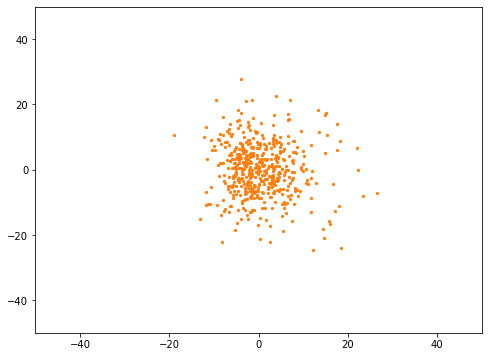

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(gau3000_unique[:,0], gau3000_unique[:,1], s=5, c='#ff7f0e')
plt.xlim(-50,50)
plt.ylim(-50,50)
# plt.savefig('init_select.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
plt.rcParams['font.family'] = 'Arial'

(-50.0, 50.0)

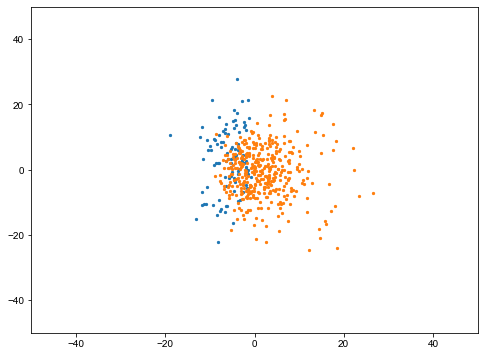

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(gau3000_unique_left[:,0], gau3000_unique_left[:,1], s=5)
plt.scatter(gau3000_unique_right[:,0], gau3000_unique_right[:,1], s=5)
plt.xlim(-50,50)
plt.ylim(-50,50)
# plt.savefig('init_part.png', bbox_inches='tight', dpi=150)

(-120.0, 120.0)

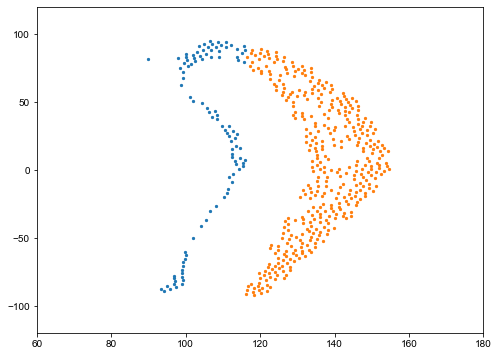

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(gau3000_target_left[:,0], gau3000_target_left[:,1], s=5)
plt.scatter(gau3000_target_right[:,0], gau3000_target_right[:,1], s=5)
plt.xlim(60,180)
plt.ylim(-120,120)
# plt.savefig('target_part.png', bbox_inches='tight', dpi=150)